In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
from google.colab import files

# Data Understanding
# Load dataset
df = pd.read_excel('/content/drive/MyDrive/ML/ispu_dki_all.csv.xlsx')
print('Shape dataset:', df.shape)
print()
df.head(10)

Shape dataset: (5538, 11)



,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK
5,2010-01-06,DKI1 (Bunderan HI),NaN,30.0,3.0,22.0,19.0,11.0,30.0,PM10,BAIK
6,2010-01-07,DKI1 (Bunderan HI),NaN,41.0,4.0,24.0,27.0,13.0,41.0,PM10,BAIK
7,2010-01-08,DKI1 (Bunderan HI),NaN,64.0,8.0,51.0,19.0,15.0,64.0,PM10,SEDANG
8,2010-01-09,DKI1 (Bunderan HI),NaN,55.0,5.0,39.0,23.0,16.0,55.0,PM10,SEDANG
9,2010-01-10,DKI1 (Bunderan HI),NaN,34.0,5.0,23.0,26.0,12.0,34.0,PM10,BAIK


In [ ]:
# Informasi tipe data
df.info()

# Statistik deskriptif
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   tanggal   5538 non-null   datetime64[ns]
 1   stasiun   5537 non-null   object        
 2   pm25      1516 non-null   float64       
 3   pm10      5223 non-null   float64       
 4   so2       5408 non-null   float64       
 5   co        5450 non-null   float64       
 6   o3        5434 non-null   float64       
 7   no2       5432 non-null   float64       
 8   max       5537 non-null   float64       
 9   critical  5534 non-null   object        
 10  categori  5538 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 476.1+ KB


,tanggal,pm25,pm10,so2,co,o3,no2,max
count,5538,1516.000000,5223.000000,5408.000000,5450.000000,5434.000000,5432.000000,5537.000000
mean,2017-07-31 12:00:00,89.742084,56.407046,22.436206,20.422752,77.465771,14.349227,97.625790
min,2010-01-01 00:00:00,10.000000,2.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,2013-10-16 06:00:00,71.000000,45.000000,10.000000,12.000000,36.000000,8.000000,70.000000
50%,2017-07-31 12:00:00,90.000000,57.000000,18.000000,18.000000,69.000000,12.000000,90.000000
75%,2021-05-15 18:00:00,107.000000,67.000000,32.000000,26.000000,103.000000,18.000000,114.000000
max,2025-02-28 00:00:00,287.000000,187.000000,112.000000,119.000000,314.000000,202.000000,314.000000
std,NaN,26.615960,20.010963,15.450584,11.966246,51.798101,10.051099,40.955382


In [ ]:
# Cek missing values
print('Missing Values:')
missing = pd.DataFrame({
    'Jumlah': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)

# Cek duplikasi
print('Jumlah duplikat:', df.duplicated().sum())

Missing Values:
          Jumlah  Persentase (%)
tanggal        0            0.00
stasiun        1            0.02
pm25        4022           72.63
pm10         315            5.69
so2          130            2.35
co            88            1.59
o3           104            1.88
no2          106            1.91
max            1            0.02
critical       4            0.07
categori       0            0.00
Jumlah duplikat: 0


Distribusi Kategori:
categori
SEDANG                3187
TIDAK SEHAT           1827
BAIK                   316
SANGAT TIDAK SEHAT     203
TIDAK ADA DATA           4
BERBAHAYA                1
Name: count, dtype: int64



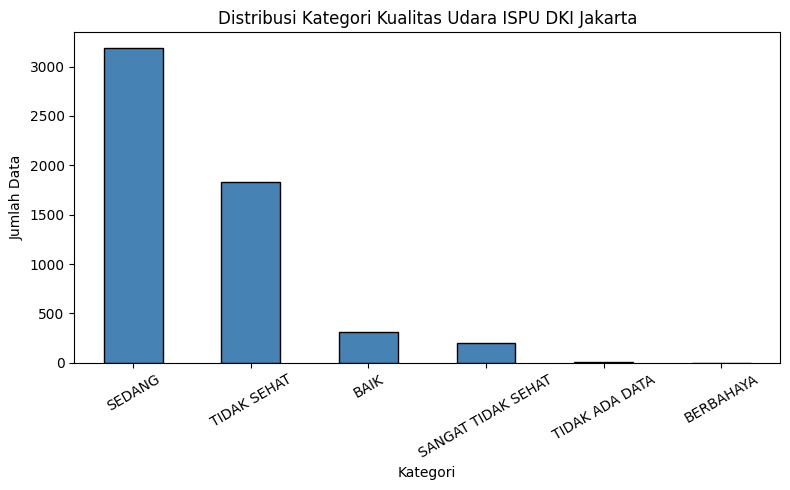

In [ ]:
# Distribusi kategori kualitas udara
print('Distribusi Kategori:')
print(df['categori'].value_counts())
print()

plt.figure(figsize=(8, 5))
df['categori'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kategori Kualitas Udara ISPU DKI Jakarta')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Distribusi data per stasiun
print('Data per Stasiun:')
print(df['stasiun'].value_counts())
print()
print('Rentang waktu data:', df['tanggal'].min(), 'sampai', df['tanggal'].max())

Data per Stasiun:
stasiun
DKI4 (Lubang Buaya)     1674
DKI2 (Kelapa Gading)    1137
DKI3 (Jagakarsa)        1116
DKI5 (Kebon Jeruk)      1079
DKI1 (Bunderan HI)       531
Name: count, dtype: int64

Rentang waktu data: 2010-01-01 00:00:00 sampai 2025-02-28 00:00:00


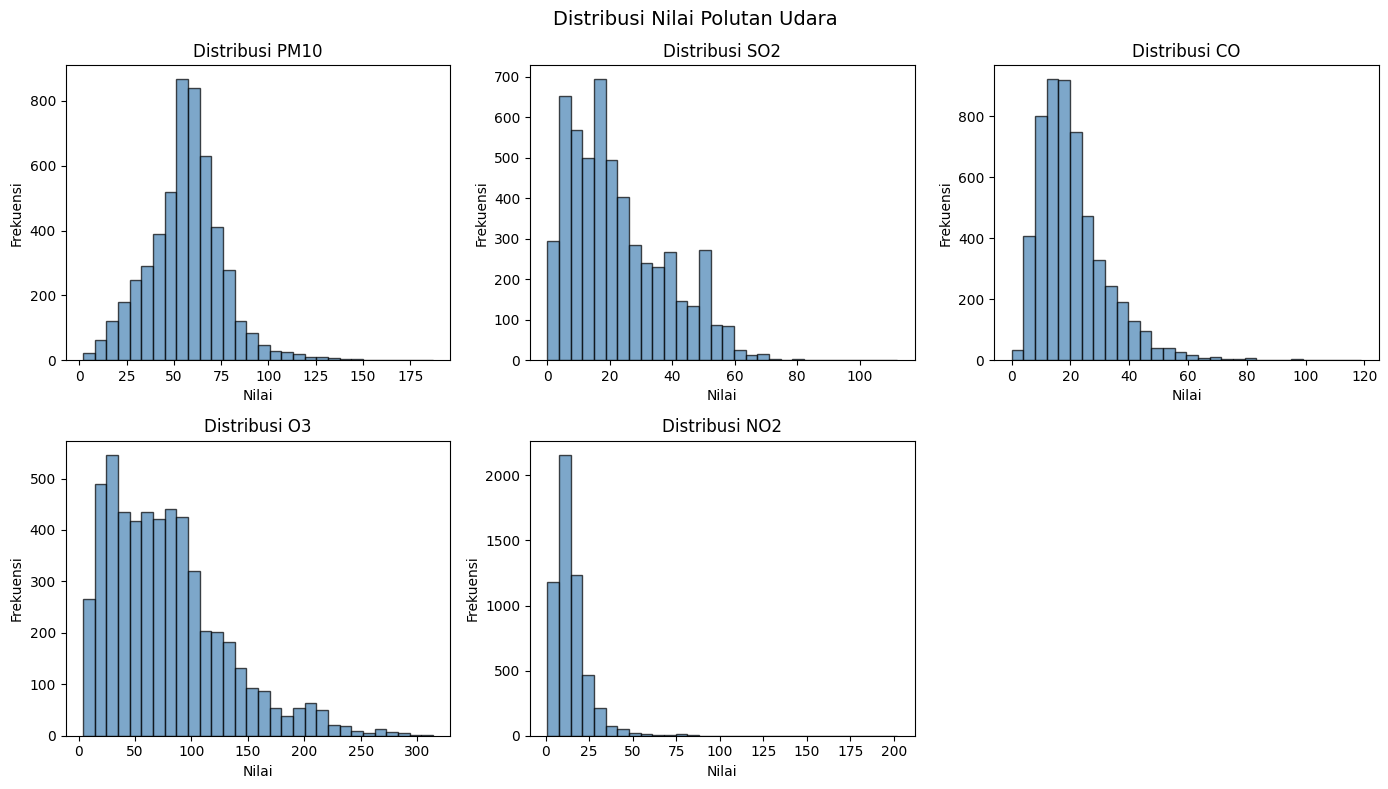

In [ ]:
# Visualisasi distribusi nilai polutan
fitur_polutan = ['pm10', 'so2', 'co', 'o3', 'no2']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(fitur_polutan):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col.upper()}')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Nilai Polutan Udara', fontsize=14)
plt.tight_layout()
plt.show()

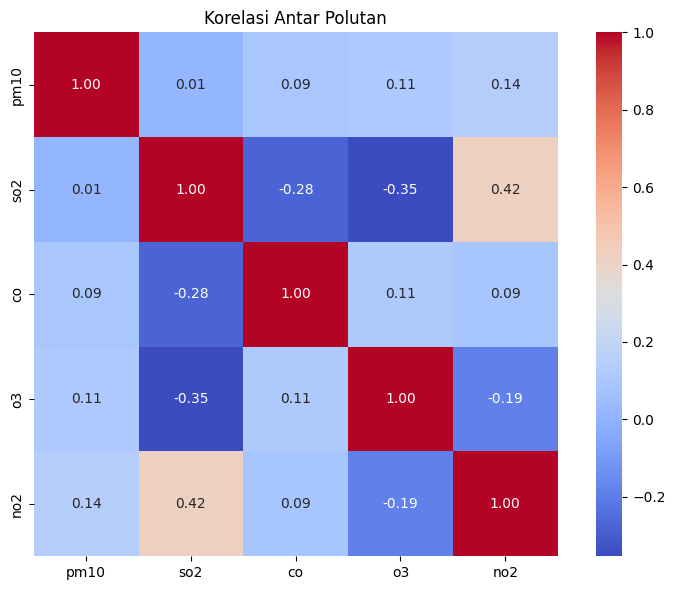

In [ ]:
# Heatmap korelasi antar polutan
plt.figure(figsize=(8, 6))
sns.heatmap(df[fitur_polutan].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Korelasi Antar Polutan')
plt.tight_layout()
plt.show()

In [ ]:
# Data Preparation
# Step 1: Hapus baris dengan label 'TIDAK ADA DATA'
df = df[df['categori'] != 'TIDAK ADA DATA']
print('Setelah hapus TIDAK ADA DATA:', len(df), 'baris')

# Step 2: Gabungkan kelas minor ke TIDAK SEHAT
# SANGAT TIDAK SEHAT (193 data) dan BERBAHAYA (1 data) terlalu sedikit untuk dilatih secara terpisah
mapping_label = {
    'BAIK': 'BAIK',
    'SEDANG': 'SEDANG',
    'TIDAK SEHAT': 'TIDAK SEHAT',
    'SANGAT TIDAK SEHAT': 'TIDAK SEHAT',
    'BERBAHAYA': 'TIDAK SEHAT'
}
df['label'] = df['categori'].map(mapping_label)
print('\nDistribusi label setelah penggabungan:')
print(df['label'].value_counts())

Setelah hapus TIDAK ADA DATA: 5534 baris

Distribusi label setelah penggabungan:
label
SEDANG         3187
TIDAK SEHAT    2031
BAIK            316
Name: count, dtype: int64


In [ ]:
# Step 3: Pilih fitur
# pm25 tidak digunakan karena 72% datanya missing (4022 dari 5538 baris)
fitur = ['pm10', 'so2', 'co', 'o3', 'no2']

# Step 4: Hapus baris yang masih memiliki missing values di fitur yang dipakai
df_model = df[fitur + ['label']].dropna()
print(f'Dataset final untuk modeling: {len(df_model)} baris')
print(df_model['label'].value_counts())

Dataset final untuk modeling: 4875 baris
label
SEDANG         2829
TIDAK SEHAT    1770
BAIK            276
Name: count, dtype: int64


In [ ]:
# Step 5: Pisahkan fitur (X) dan label (y)
X = df_model[fitur]
y = df_model['label']

# Step 6: Split data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data training : {len(X_train)} baris')
print(f'Data testing  : {len(X_test)} baris')

Data training : 3900 baris
Data testing  : 975 baris


In [ ]:
# Modeling
# Training model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # jumlah pohon
    random_state=42,
    class_weight='balanced'  # menangani ketidakseimbangan kelas
)
rf_model.fit(X_train, y_train)
print('✅ Model Random Forest berhasil dilatih!')
print(f'Jumlah pohon: {rf_model.n_estimators}')
print(f'Fitur yang digunakan: {fitur}')

✅ Model Random Forest berhasil dilatih!
Jumlah pohon: 100
Fitur yang digunakan: ['pm10', 'so2', 'co', 'o3', 'no2']


Feature Importance:
o3      0.504346
pm10    0.281543
so2     0.103832
no2     0.060879
co      0.049400
dtype: float64


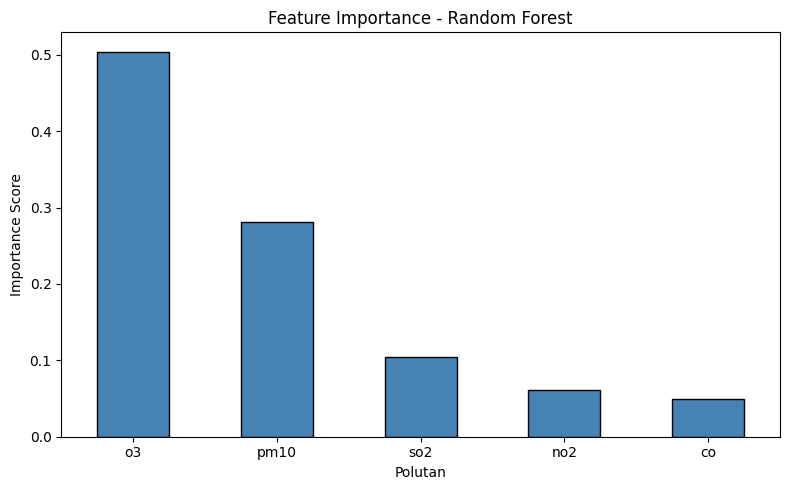

In [ ]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=fitur).sort_values(ascending=False)
print('Feature Importance:')
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Polutan')
plt.ylabel('Importance Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation
# Prediksi data testing
y_pred = rf_model.predict(X_test)

# Akurasi
acc = accuracy_score(y_test, y_pred)
print(f'Akurasi Model: {acc:.4f} ({acc*100:.2f}%)')
print()

# Classification Report (Precision, Recall, F1-Score)
print('Classification Report:')
print(classification_report(y_test, y_pred))

Akurasi Model: 0.9528 (95.28%)

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.94      0.84      0.88        55
      SEDANG       0.95      0.98      0.96       566
 TIDAK SEHAT       0.97      0.94      0.95       354

    accuracy                           0.95       975
   macro avg       0.95      0.92      0.93       975
weighted avg       0.95      0.95      0.95       975



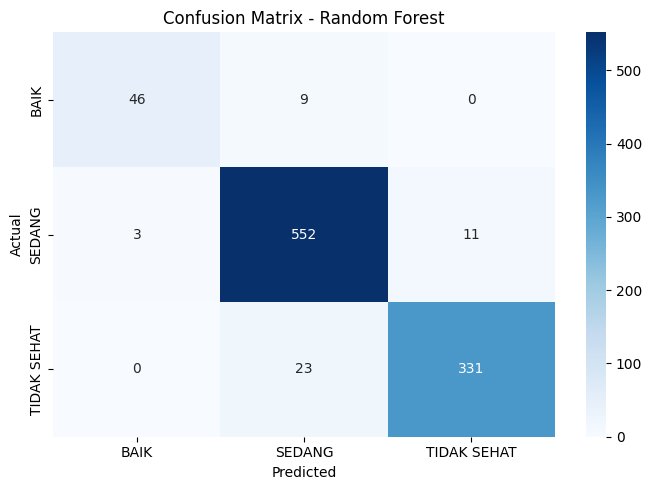

In [ ]:
# Confusion Matrix
labels = ['BAIK', 'SEDANG', 'TIDAK SEHAT']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Simpan model
joblib.dump(rf_model, 'rf_ispu_model.pkl')
print('✅ Model disimpan sebagai rf_ispu_model.pkl')

# Download model dari Colab
files.download('rf_ispu_model.pkl')

✅ Model disimpan sebagai rf_ispu_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Contoh prediksi data baru
# Format input: [pm10, so2, co, o3, no2]
data_baru = pd.DataFrame({
    'pm10': [90],
    'so2':  [5],
    'co':   [50],
    'o3':   [30],
    'no2':  [12]
})

hasil = rf_model.predict(data_baru)
proba = rf_model.predict_proba(data_baru)

print(f'Prediksi Kategori Kualitas Udara: {hasil[0]}')
print()
print('Probabilitas per kelas:')
for cls, prob in zip(rf_model.classes_, proba[0]):
    print(f'  {cls}: {prob*100:.1f}%')

Prediksi Kategori Kualitas Udara: SEDANG

Probabilitas per kelas:
  BAIK: 0.0%
  SEDANG: 96.0%
  TIDAK SEHAT: 4.0%
